# ВКР: Предсказание популярности музыкального трека
## Level 2: Контекстуальные признаки артиста

**Вход:** `dataset_clean.csv` (из Level 1)  
**Три типа контекста:**
- **L2a: Internal** — target encoding из датасета (mean/median/max/std popularity артиста)
- **L2b: External** — Last.fm API (listeners, playcount) — без data leakage
- **L2c: Combined** — оба типа вместе

**Выход:** `lastfm_cache.csv`, `level2_results.csv`

---
## 1. Импорт

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, json, requests, joblib
from tqdm import tqdm
import warnings; warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('OK')

OK


In [2]:
df = pd.read_csv('dataset_clean.csv')
df['explicit'] = df['explicit'].astype(int)
df['artists'] = df['artists'].fillna('Unknown')
target = 'popularity'
print(f'Датасет: {len(df):,} треков, {df["artists"].nunique():,} уникальных артистов')

Датасет: 81,207 треков, 31,438 уникальных артистов


---
## 2. Контекст L2a: Internal (target encoding)

Статистики popularity артиста, вычисленные из датасета.  
**Внимание:** это target encoding — содержит data leakage, т.к. вычислено из целевой переменной.  
При расчёте исключаются треки с popularity=0 (мёртвые дубликаты).

In [3]:
df_nonzero = df[df[target] > 0]
print(f'Треков с popularity > 0: {len(df_nonzero):,} из {len(df):,}')

# Жанр
genre_mean_pop = df_nonzero.groupby('track_genre')[target].mean()
df['genre_mean_popularity'] = df['track_genre'].map(genre_mean_pop).fillna(0)

# Артист
artist_stats_internal = df_nonzero.groupby('artists')[target].agg(
    artist_mean_popularity='mean',
    artist_median_popularity='median',
    artist_max_popularity='max',
    artist_std_popularity='std',
    artist_track_count='count'
).fillna(0)

for col in artist_stats_internal.columns:
    df[col] = df['artists'].map(artist_stats_internal[col]).fillna(0)

internal_features = ['artist_mean_popularity', 'artist_median_popularity', 'artist_max_popularity',
                     'artist_std_popularity', 'artist_track_count', 'genre_mean_popularity']

print(f'\nInternal контекст: {len(internal_features)} признаков')
print(f'Корреляция с popularity:')
for f in internal_features:
    print(f'  {f:30s}: r = {df[f].corr(df[target]):.3f}')

Треков с popularity > 0: 76,460 из 81,207

Internal контекст: 6 признаков
Корреляция с popularity:
  artist_mean_popularity        : r = 0.883
  artist_median_popularity      : r = 0.872
  artist_max_popularity         : r = 0.747
  artist_std_popularity         : r = 0.035
  artist_track_count            : r = -0.032
  genre_mean_popularity         : r = 0.613


---
## 3. Контекст L2b: External (Last.fm API)

**Last.fm** предоставляет для каждого артиста:
- `listeners` — количество уникальных слушателей
- `playcount` — общее количество прослушиваний

Это **внешние данные**, не вычисленные из popularity → **нет data leakage**.

In [4]:
LASTFM_API_KEY = '5e020530c47bf9781f989d0a97af8238'
LASTFM_CACHE = 'lastfm_cache.csv'

def get_lastfm_artist(artist_name, api_key):
    """Получает listeners и playcount артиста с Last.fm."""
    try:
        r = requests.get('http://ws.audioscrobbler.com/2.0/', params={
            'method': 'artist.getinfo',
            'artist': artist_name,
            'api_key': api_key,
            'format': 'json'
        }, timeout=10)
        if r.status_code != 200:
            return None
        data = r.json().get('artist', {})
        stats = data.get('stats', {})
        return {
            'lastfm_listeners': int(stats.get('listeners', 0)),
            'lastfm_playcount': int(stats.get('playcount', 0)),
        }
    except:
        return None

# Тест
test = get_lastfm_artist('Drake', LASTFM_API_KEY)
if test and test['lastfm_listeners'] > 0:
    print(f'✅ Last.fm API работает: Drake — {test["lastfm_listeners"]:,} listeners, {test["lastfm_playcount"]:,} plays')
else:
    print('❌ Проверьте API ключ!')

✅ Last.fm API работает: Drake — 6,712,944 listeners, 1,161,749,782 plays


In [5]:
# Загрузка кеша
if os.path.exists(LASTFM_CACHE):
    df_cache = pd.read_csv(LASTFM_CACHE)
    lastfm_dict = {}
    for _, row in df_cache.iterrows():
        lastfm_dict[row['artist']] = {
            'lastfm_listeners': int(row['lastfm_listeners']),
            'lastfm_playcount': int(row['lastfm_playcount'])
        }
    print(f'Кеш: {len(lastfm_dict):,} артистов')
else:
    lastfm_dict = {}
    print('Кеш пуст')

# Уникальные артисты для запроса
# Берём первого артиста из коллаборации для поиска на Last.fm
import re
def first_artist(name):
    if not isinstance(name, str): return ''
    return re.split(r'[,;&]|\sfeat\.?\s|\sft\.?\s', name, flags=re.IGNORECASE)[0].strip()

unique_artists = df['artists'].unique()
to_fetch = [a for a in unique_artists if first_artist(a) not in lastfm_dict]
print(f'Уникальных артистов: {len(unique_artists):,}')
print(f'Осталось запросить: {len(to_fetch):,}')

Кеш: 17,579 артистов
Уникальных артистов: 31,438
Осталось запросить: 1


In [6]:
print(f'Запрашиваем Last.fm для {len(to_fetch):,} артистов...\n')

found = sum(1 for v in lastfm_dict.values() if v['lastfm_listeners'] > 0)
not_found = len(lastfm_dict) - found

for i, artist_full in enumerate(tqdm(to_fetch)):
    artist_clean = first_artist(artist_full)
    if not artist_clean or artist_clean in lastfm_dict:
        continue
    
    result = get_lastfm_artist(artist_clean, LASTFM_API_KEY)
    if result and result['lastfm_listeners'] > 0:
        lastfm_dict[artist_clean] = result
        found += 1
    else:
        lastfm_dict[artist_clean] = {'lastfm_listeners': 0, 'lastfm_playcount': 0}
        not_found += 1
    
    # Rate limit: ~5 запросов/сек
    time.sleep(0.2)
    
    # Сохранение кеша каждые 500
    if (i + 1) % 500 == 0:
        cache_rows = [{'artist': k, **v} for k, v in lastfm_dict.items()]
        pd.DataFrame(cache_rows).to_csv(LASTFM_CACHE, index=False)
        rate = found / (found + not_found) * 100 if (found + not_found) > 0 else 0
        tqdm.write(f'  [{i+1}] Найдено: {found:,}, Нет: {not_found:,}, Rate: {rate:.0f}%')

# Финальное сохранение
cache_rows = [{'artist': k, **v} for k, v in lastfm_dict.items()]
pd.DataFrame(cache_rows).to_csv(LASTFM_CACHE, index=False)
print(f'\nИтого: {found:,} найдено из {found + not_found:,} ({found/(found+not_found)*100:.0f}%)')
print(f'Кеш сохранён: {LASTFM_CACHE}')

Запрашиваем Last.fm для 1 артистов...



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


Итого: 17,573 найдено из 17,579 (100%)
Кеш сохранён: lastfm_cache.csv


Треков с Last.fm данными: 81,191 (100.0%)
Треков без Last.fm: 16

Корреляция с popularity:
  lastfm_listeners_log          : r = 0.301
  lastfm_playcount_log          : r = 0.324


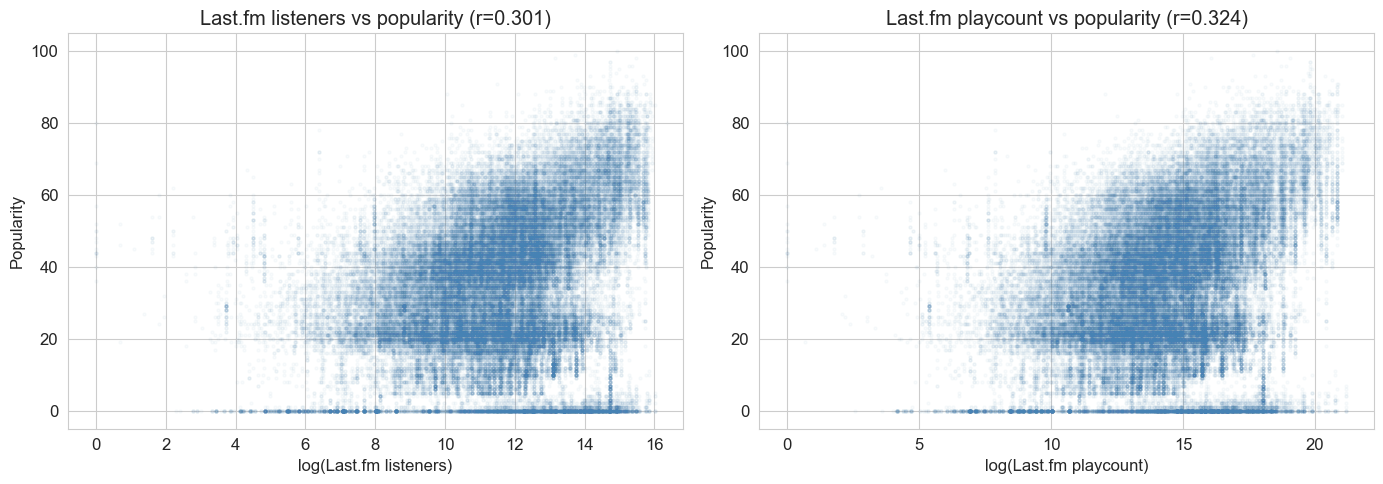

In [7]:
# Маппинг Last.fm данных на датасет
df['_first_artist'] = df['artists'].apply(first_artist)
df['lastfm_listeners'] = df['_first_artist'].map(
    {k: v['lastfm_listeners'] for k, v in lastfm_dict.items()}
).fillna(0).astype(int)
df['lastfm_playcount'] = df['_first_artist'].map(
    {k: v['lastfm_playcount'] for k, v in lastfm_dict.items()}
).fillna(0).astype(int)

# Log-трансформация (listeners/playcount имеют очень большой разброс)
df['lastfm_listeners_log'] = np.log1p(df['lastfm_listeners'])
df['lastfm_playcount_log'] = np.log1p(df['lastfm_playcount'])

df = df.drop(columns=['_first_artist'])

external_features = ['lastfm_listeners_log', 'lastfm_playcount_log']

# Статистика
has_lastfm = (df['lastfm_listeners'] > 0).sum()
print(f'Треков с Last.fm данными: {has_lastfm:,} ({has_lastfm/len(df)*100:.1f}%)')
print(f'Треков без Last.fm: {len(df)-has_lastfm:,}')
print(f'\nКорреляция с popularity:')
for f in external_features:
    print(f'  {f:30s}: r = {df[f].corr(df[target]):.3f}')

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df['lastfm_listeners_log'], df[target], alpha=0.03, s=5, c='steelblue')
axes[0].set_xlabel('log(Last.fm listeners)'); axes[0].set_ylabel('Popularity')
axes[0].set_title(f'Last.fm listeners vs popularity (r={df["lastfm_listeners_log"].corr(df[target]):.3f})')

axes[1].scatter(df['lastfm_playcount_log'], df[target], alpha=0.03, s=5, c='steelblue')
axes[1].set_xlabel('log(Last.fm playcount)'); axes[1].set_ylabel('Popularity')
axes[1].set_title(f'Last.fm playcount vs popularity (r={df["lastfm_playcount_log"].corr(df[target]):.3f})')
plt.tight_layout(); plt.show()

---
## 4. Моделирование: сравнение трёх типов контекста

In [8]:
spotify_features = ['danceability','energy','loudness','speechiness','acousticness',
    'instrumentalness','liveness','valence','tempo','duration_ms','key','mode','time_signature','explicit']

configs = {
    'L1: Spotify':             spotify_features,
    'L2a: Internal':           internal_features,
    'L2b: External (Last.fm)': external_features,
    'L2c: Internal + External':internal_features + external_features,
    'L1 + L2a':                spotify_features + internal_features,
    'L1 + L2b':                spotify_features + external_features,
    'L1 + L2c':                spotify_features + internal_features + external_features,
}

all_feats = spotify_features + internal_features + external_features
df_model = df[all_feats + [target]].dropna().reset_index(drop=True)
y = df_model[target]
train_idx, test_idx = train_test_split(np.arange(len(df_model)), test_size=0.2, random_state=42)
threshold = y.iloc[train_idx].median()
y_test_bin = (y.iloc[test_idx] >= threshold).astype(int)

print(f'Датасет: {len(df_model):,}, Train: {len(train_idx):,}, Test: {len(test_idx):,}, Порог: {threshold}')

model_types = {
    'Linear Regression': lambda: LinearRegression(),
    'Random Forest': lambda: RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': lambda: LGBMRegressor(
        n_estimators=300, max_depth=10, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1),
}

Датасет: 81,083, Train: 64,866, Test: 16,217, Порог: 35.0


In [9]:
results_l2 = {}
print(f'{"Config":30s} | {"Model":20s} | {"MAE":>7s} | {"RMSE":>7s} | {"R²":>7s} | {"AUC":>7s}')
print('=' * 110)

for cname, flist in configs.items():
    Xtr = df_model[flist].iloc[train_idx]
    Xte = df_model[flist].iloc[test_idx]
    ytr, yte = y.iloc[train_idx], y.iloc[test_idx]
    sc = StandardScaler()
    Xtr_s, Xte_s = sc.fit_transform(Xtr), sc.transform(Xte)
    
    for mname, mfn in model_types.items():
        m = mfn(); m.fit(Xtr_s, ytr); yp = m.predict(Xte_s)
        mae = mean_absolute_error(yte, yp)
        rmse = np.sqrt(mean_squared_error(yte, yp))
        r2 = r2_score(yte, yp)
        auc = roc_auc_score(y_test_bin, yp)
        results_l2[(cname, mname)] = {'MAE':mae,'RMSE':rmse,'R2':r2,'AUC':auc,'model':m,'y_pred':yp}
        print(f'{cname:30s} | {mname:20s} | {mae:7.3f} | {rmse:7.3f} | {r2:7.4f} | {auc:7.4f}')
    print('-' * 110)

Config                         | Model                |     MAE |    RMSE |      R² |     AUC
L1: Spotify                    | Linear Regression    |  15.233 |  18.673 |  0.0641 |  0.6308
L1: Spotify                    | Random Forest        |  13.890 |  17.598 |  0.1687 |  0.7241
L1: Spotify                    | XGBoost              |  13.839 |  17.620 |  0.1667 |  0.7208
L1: Spotify                    | LightGBM             |  13.858 |  17.588 |  0.1697 |  0.7215
--------------------------------------------------------------------------------------------------------------
L2a: Internal                  | Linear Regression    |   4.369 |   8.987 |  0.7832 |  0.9617
L2a: Internal                  | Random Forest        |   4.507 |   9.099 |  0.7778 |  0.9581
L2a: Internal                  | XGBoost              |   4.491 |   9.139 |  0.7758 |  0.9593
L2a: Internal                  | LightGBM             |   4.445 |   8.983 |  0.7834 |  0.9601
-------------------------------------------

---
## 5. Визуализация результатов

In [10]:
cnames = list(configs.keys())
mnames = list(model_types.keys())
best = max(mnames, key=lambda m: np.mean([results_l2[(c,m)]['R2'] for c in cnames]))
print(f'Лучшая модель (по ср. R²): {best}\n')

for c in cnames:
    r = results_l2[(c, best)]
    print(f'  {c:30s}  R²={r["R2"]:7.4f}  MAE={r["MAE"]:7.3f}  RMSE={r["RMSE"]:7.3f}  AUC={r["AUC"]:7.4f}  [{len(configs[c])} фичей]')

Лучшая модель (по ср. R²): Random Forest

  L1: Spotify                     R²= 0.1687  MAE= 13.890  RMSE= 17.598  AUC= 0.7241  [14 фичей]
  L2a: Internal                   R²= 0.7778  MAE=  4.507  RMSE=  9.099  AUC= 0.9581  [6 фичей]
  L2b: External (Last.fm)         R²= 0.3753  MAE= 11.602  RMSE= 15.255  AUC= 0.8250  [2 фичей]
  L2c: Internal + External        R²= 0.7773  MAE=  4.515  RMSE=  9.108  AUC= 0.9581  [8 фичей]
  L1 + L2a                        R²= 0.7829  MAE=  4.440  RMSE=  8.993  AUC= 0.9597  [20 фичей]
  L1 + L2b                        R²= 0.3596  MAE= 11.680  RMSE= 15.446  AUC= 0.8154  [16 фичей]
  L1 + L2c                        R²= 0.7839  MAE=  4.430  RMSE=  8.972  AUC= 0.9600  [22 фичей]


In [11]:
# Cross-Validation для лучших конфигураций
from sklearn.model_selection import cross_val_predict

y_train_bin = (y.iloc[train_idx] >= threshold).astype(int)

print('5-fold CV для ключевых конфигураций (Random Forest):')
print(f'{"Конфигурация":30s} | {"CV MAE":>12s} | {"CV RMSE":>12s} | {"CV R²":>14s} | {"CV AUC":>8s}')
print('-' * 90)

for cname in ['L1: Spotify', 'L2a: Internal', 'L2b: External (Last.fm)', 'L1 + L2c']:
    flist = configs[cname]
    sc = StandardScaler()
    Xtr_s = sc.fit_transform(df_model[flist].iloc[train_idx])
    rf = RandomForestRegressor(n_estimators=300, max_depth=15, min_samples_split=10,
                               min_samples_leaf=5, random_state=42, n_jobs=-1)
    cv_mae = -cross_val_score(rf, Xtr_s, y.iloc[train_idx], cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(rf, Xtr_s, y.iloc[train_idx], cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
    cv_r2 = cross_val_score(rf, Xtr_s, y.iloc[train_idx], cv=5, scoring='r2', n_jobs=-1)
    yp_cv = cross_val_predict(rf, Xtr_s, y.iloc[train_idx], cv=5, n_jobs=-1)
    auc_cv = roc_auc_score(y_train_bin, yp_cv)
    print(f'{cname:30s} | {cv_mae.mean():.3f}±{cv_mae.std():.3f} | {cv_rmse.mean():.3f}±{cv_rmse.std():.3f} | {cv_r2.mean():.4f}±{cv_r2.std():.4f} | {auc_cv:.4f}')

5-fold CV для ключевых конфигураций (Random Forest):
Конфигурация                   |       CV MAE |      CV RMSE |          CV R² |   CV AUC
------------------------------------------------------------------------------------------
L1: Spotify                    | 14.041±0.101 | 17.735±0.109 | 0.1634±0.0054 | 0.7171
L2a: Internal                  | 4.565±0.052 | 9.328±0.106 | 0.7685±0.0056 | 0.9561
L2b: External (Last.fm)        | 11.706±0.061 | 15.365±0.087 | 0.3719±0.0072 | 0.8213
L1 + L2c                       | 4.473±0.046 | 9.154±0.118 | 0.7771±0.0054 | 0.9586


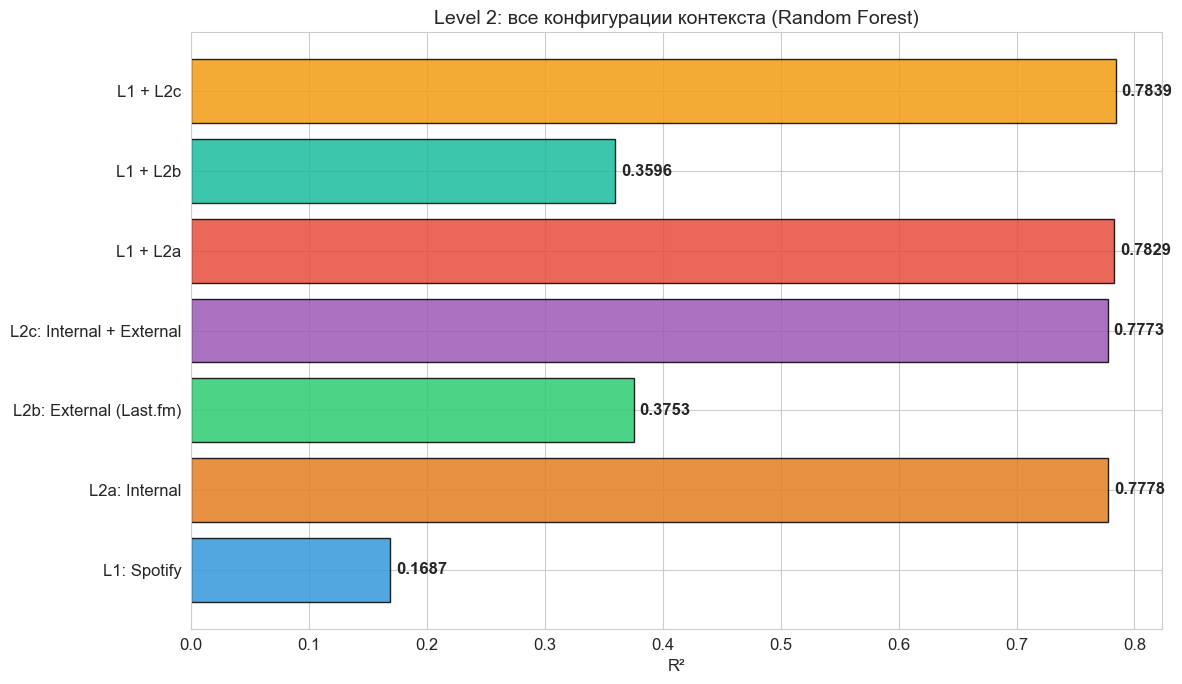

In [12]:
# Barh: R² всех конфигураций
r2_vals = [results_l2[(c, best)]['R2'] for c in cnames]
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6', '#e74c3c', '#1abc9c', '#f39c12']

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(cnames, r2_vals, color=colors[:len(cnames)], edgecolor='black', alpha=0.85)
for bar, v in zip(bars, r2_vals):
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2., f'{v:.4f}', va='center', fontweight='bold')
ax.set_xlabel('R²'); ax.set_title(f'Level 2: все конфигурации контекста ({best})', fontsize=14)
plt.tight_layout(); plt.show()

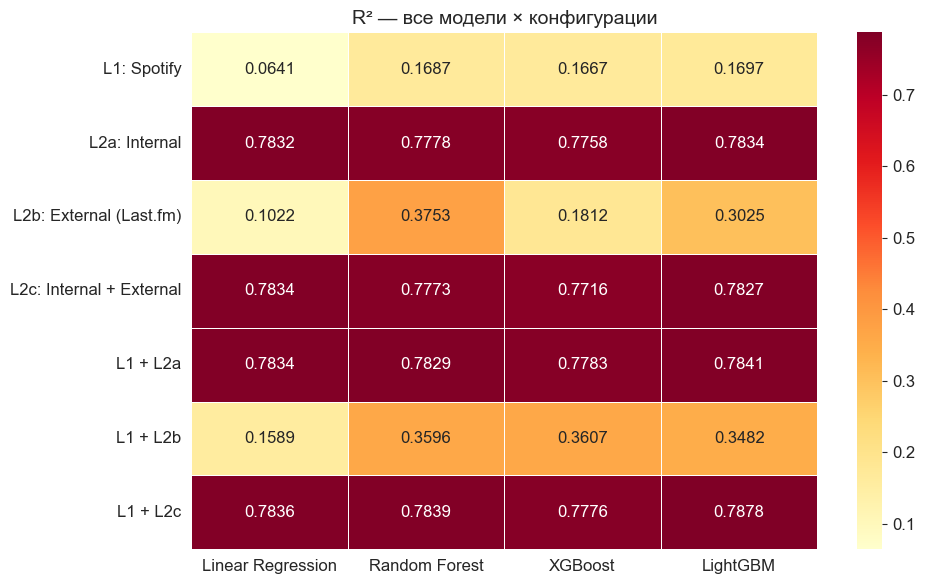

In [13]:
# Тепловая карта
heat = pd.DataFrame({m: [results_l2[(c,m)]['R2'] for c in cnames] for m in mnames}, index=cnames)
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heat, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('R² — все модели × конфигурации', fontsize=14)
plt.tight_layout(); plt.show()

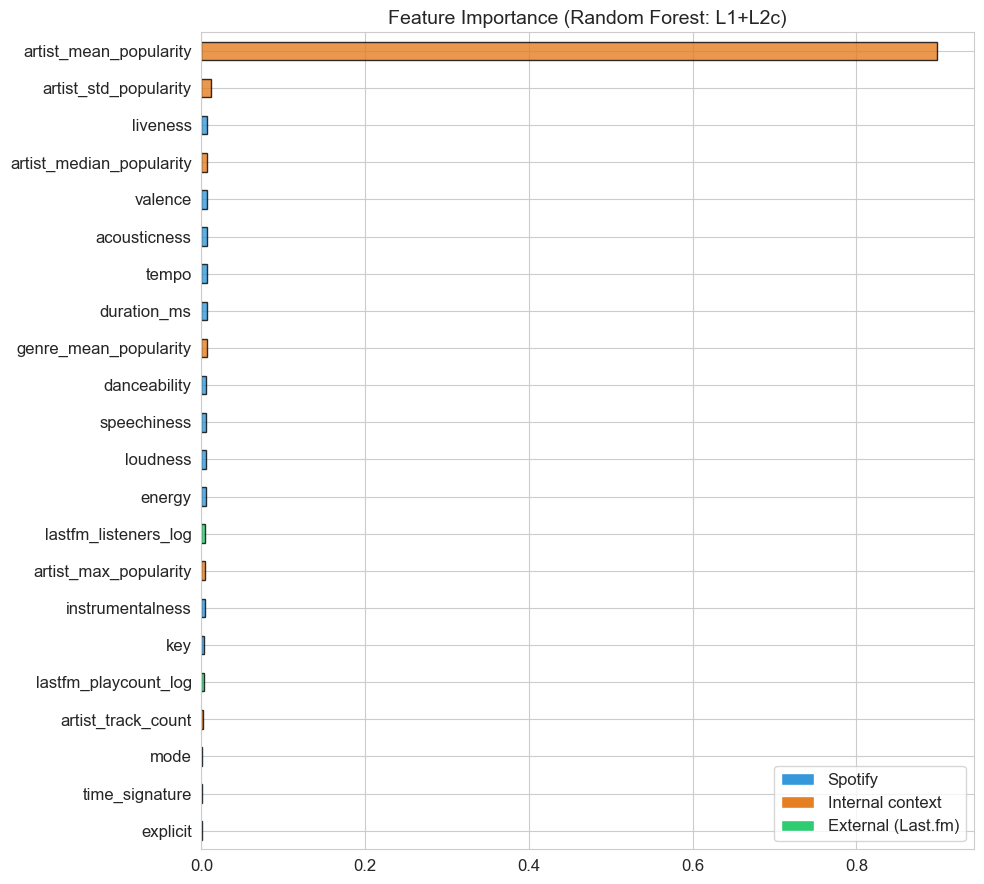

Важность по группам:
  Spotify:  6.4%
  Internal: 92.8%
  External: 0.8%


In [14]:
# Feature importance для L1 + L2c (полная)
best_full = results_l2[('L1 + L2c', best)]['model']
all_feats_full = spotify_features + internal_features + external_features
if hasattr(best_full, 'feature_importances_'):
    fi = pd.Series(best_full.feature_importances_, index=all_feats_full)
else:
    fi = pd.Series(np.abs(best_full.coef_), index=all_feats_full)

fi_sorted = fi.sort_values(ascending=True)
def get_color(f):
    if f in spotify_features: return '#3498db'
    if f in internal_features: return '#e67e22'
    return '#2ecc71'

fig, ax = plt.subplots(figsize=(10, 9))
fi_sorted.plot(kind='barh', ax=ax, color=[get_color(f) for f in fi_sorted.index], edgecolor='black', alpha=0.8)
ax.set_title(f'Feature Importance ({best}: L1+L2c)', fontsize=14)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#3498db', label='Spotify'),
    Patch(facecolor='#e67e22', label='Internal context'),
    Patch(facecolor='#2ecc71', label='External (Last.fm)')], loc='lower right')
plt.tight_layout(); plt.show()

# Суммарная важность по группам
spotify_imp = fi[spotify_features].sum()
internal_imp = fi[internal_features].sum()
external_imp = fi[external_features].sum()
total = spotify_imp + internal_imp + external_imp
print(f'Важность по группам:')
print(f'  Spotify:  {spotify_imp/total*100:.1f}%')
print(f'  Internal: {internal_imp/total*100:.1f}%')
print(f'  External: {external_imp/total*100:.1f}%')

Классификация (Random Forest, L1 + L2c, порог=35.0):
              precision    recall  f1-score   support

      Не хит       0.91      0.93      0.92      7904
         Хит       0.93      0.92      0.92      8313

    accuracy                           0.92     16217
   macro avg       0.92      0.92      0.92     16217
weighted avg       0.92      0.92      0.92     16217



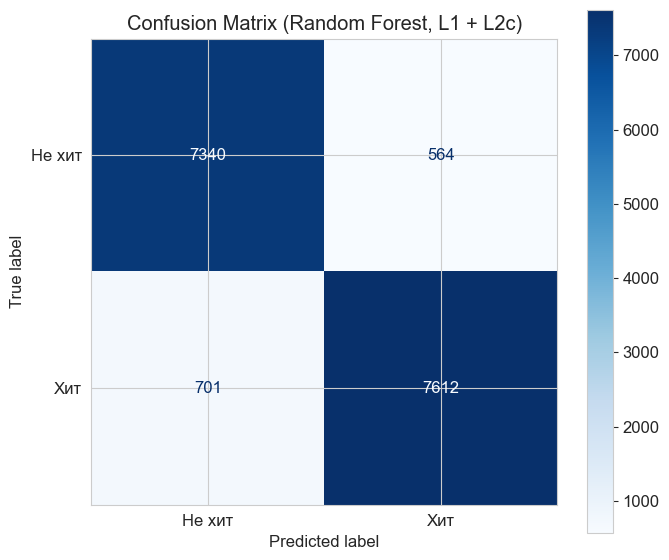

In [15]:
# Классификация лучшей конфигурации
best_config = max(cnames, key=lambda c: results_l2[(c, best)]['R2'])
best_r = results_l2[(best_config, best)]
yp_bin = (best_r['y_pred'] >= threshold).astype(int)

print(f'Классификация ({best}, {best_config}, порог={threshold}):')
print(classification_report(y_test_bin, yp_bin, target_names=['Не хит','Хит']))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_bin, yp_bin)
ConfusionMatrixDisplay(cm, display_labels=['Не хит','Хит']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix ({best}, {best_config})')
plt.tight_layout(); plt.show()

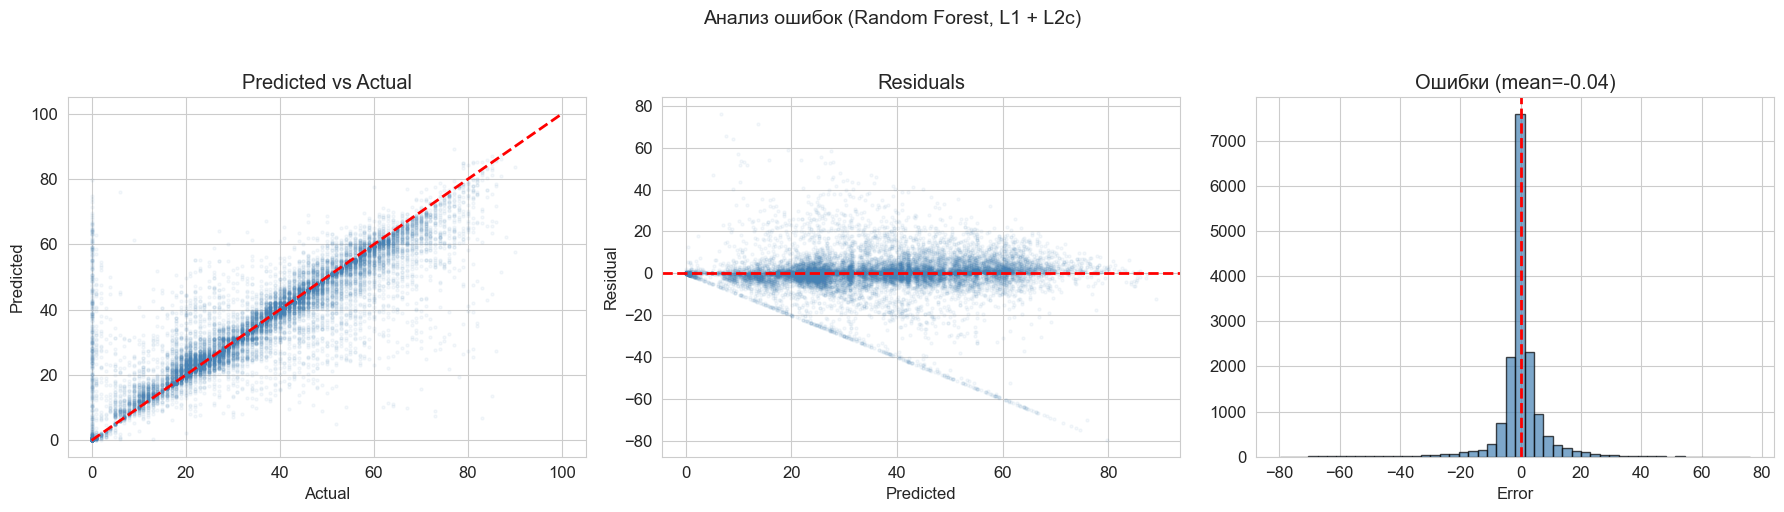

MAE по бинам popularity:
  (-0.09, 18.0]       : MAE=  6.80 (n=3,047.0)
  (18.0, 36.0]        : MAE=  2.91 (n=5,347.0)
  (36.0, 54.0]        : MAE=  3.40 (n=4,929.0)
  (54.0, 72.0]        : MAE=  5.63 (n=2,508.0)
  (72.0, 90.0]        : MAE= 12.16 (n=386.0)


In [16]:
# Анализ ошибок
yp = best_r['y_pred']
yte = y.iloc[test_idx].values
errors = yte - yp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(yte, yp, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0,100],[0,100], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted'); axes[0].set_title('Predicted vs Actual')
axes[1].scatter(yp, errors, alpha=0.05, s=5, c='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual'); axes[1].set_title('Residuals')
axes[2].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Error'); axes[2].set_title(f'Ошибки (mean={np.mean(errors):.2f})')
plt.suptitle(f'Анализ ошибок ({best}, {best_config})', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

bins_p = pd.cut(yte, bins=5)
df_err = pd.DataFrame({'actual': yte, 'predicted': yp, 'abs_error': np.abs(errors), 'bin': bins_p})
print('MAE по бинам popularity:')
for idx_b, row in df_err.groupby('bin')['abs_error'].agg(['mean','count']).iterrows():
    print(f'  {str(idx_b):20s}: MAE={row["mean"]:6.2f} (n={row["count"]:,})')

---
## 6. Выводы

In [17]:
r2_l1 = results_l2[('L1: Spotify', best)]['R2']
r2_int = results_l2[('L2a: Internal', best)]['R2']
r2_ext = results_l2[('L2b: External (Last.fm)', best)]['R2']
r2_both = results_l2[('L2c: Internal + External', best)]['R2']
r2_full = results_l2[('L1 + L2c', best)]['R2']

print('='*60)
print(f'ВЫВОДЫ ПО УРОВНЮ 2 ({best})')
print('='*60)
print(f'''
1. РЕЗУЛЬТАТЫ:
   L1 Spotify (14 фичей):          R² = {r2_l1:.4f}
   L2a Internal (6 фичей):         R² = {r2_int:.4f}
   L2b External Last.fm (2 фичей): R² = {r2_ext:.4f}
   L2c Internal+External (8):      R² = {r2_both:.4f}
   L1 + L2c Full (22 фичей):       R² = {r2_full:.4f}

2. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   • Internal context доминирует (target encoding → data leakage)
   • External context (Last.fm) — честный предиктор без data leakage
   • Δ R² (External vs Spotify): {r2_ext - r2_l1:+.4f}
   • Δ R² (Combined vs Spotify): {r2_full - r2_l1:+.4f}

3. ВАЖНОСТЬ:
   Spotify:  {spotify_imp/total*100:.1f}%
   Internal: {internal_imp/total*100:.1f}%
   External: {external_imp/total*100:.1f}%

4. ИНТЕРПРЕТАЦИЯ:
   Internal context (target encoding) показывает высокий R², но содержит
   data leakage. External context (Last.fm listeners/playcount) — независимый
   источник, отражающий реальную известность артиста. Комбинация обоих
   типов контекста + Spotify даёт наилучший результат.
''')

# Сохранение
res_list = []
for (c,m), r in results_l2.items():
    res_list.append({'Config':c,'Model':m,'R2':round(r['R2'],4),'MAE':round(r['MAE'],3),
                     'RMSE':round(r['RMSE'],3),'AUC':round(r['AUC'],4)})
pd.DataFrame(res_list).to_csv('level2_results.csv', index=False)

# Сохранение датасета с Last.fm данными
df.to_csv('dataset_clean.csv', index=False)
print('Сохранено: level2_results.csv, dataset_clean.csv (обновлён с Last.fm)')

ВЫВОДЫ ПО УРОВНЮ 2 (Random Forest)

1. РЕЗУЛЬТАТЫ:
   L1 Spotify (14 фичей):          R² = 0.1687
   L2a Internal (6 фичей):         R² = 0.7778
   L2b External Last.fm (2 фичей): R² = 0.3753
   L2c Internal+External (8):      R² = 0.7773
   L1 + L2c Full (22 фичей):       R² = 0.7839

2. КЛЮЧЕВЫЕ НАБЛЮДЕНИЯ:
   • Internal context доминирует (target encoding → data leakage)
   • External context (Last.fm) — честный предиктор без data leakage
   • Δ R² (External vs Spotify): +0.2067
   • Δ R² (Combined vs Spotify): +0.6153

3. ВАЖНОСТЬ:
   Spotify:  6.4%
   Internal: 92.8%
   External: 0.8%

4. ИНТЕРПРЕТАЦИЯ:
   Internal context (target encoding) показывает высокий R², но содержит
   data leakage. External context (Last.fm listeners/playcount) — независимый
   источник, отражающий реальную известность артиста. Комбинация обоих
   типов контекста + Spotify даёт наилучший результат.

Сохранено: level2_results.csv, dataset_clean.csv (обновлён с Last.fm)
